In [1]:
"""C 2023 Matthew C. Digman
Notebook to Demonstrate Capabilities of DTMCMC on Gaussian likelihood"""

# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.

# import needed libaries 
import numpy as np
from numba import njit

import matplotlib.pyplot as plt

from DTMCMC.ptmcmc_helpers import PTMCMCChain
from DTMCMC.temperature_ladder_helpers import TemperatureLadder
import DTMCMC.temperature_ladder_helpers as th
from DTMCMC.corr_summary_helpers import CorrelationSummary
from DTMCMC.proposal_strategy_helpers import ProposalStrategyParameters

import DTMCMC.fisher_manager as fm
import DTMCMC.de_manager as dm
import DTMCMC.prior_manager as pm
import DTMCMC.auxilliary_manager as am
import DTMCMC.exchange_manager as eh

from DTMCMC.proposal_manager import ProposalManager

from DTMCMC.correction_helpers import reflect_into_range

import diagnostic_commentary_helpers as dch


In [2]:
# This is an example likelihood object for a gaussian likelihod
# In many cases this may be the only thing that needs to be modified to extend the sampler

class Likelihood():
    """class to manage the likelihood-specific essential functions for the sampler"""
    def __init__(self,n_par=100,eps_default=1.e-4,cutoff=5):
        """create the class and store any object specific variables"""
        self.n_par = n_par
        self.epsilons = np.zeros(n_par)+eps_default
        self.cutoff = cutoff

    def get_loglike(self,v):
        """get the log likelihood given a set of parameters v"""
        return get_loglike(v)

    def prior_draw(self):
        """get a draw from the prior"""
        return prior_draw(self.n_par,self.cutoff)

    def prior_proposal(self,v_in):
        """get a proposal from the prior"""
        v_out = prior_draw(self.n_par,self.cutoff)
        return v_out,prior_factor(v_in,self.n_par)-prior_factor(v_out,self.n_par),True

    def prior_factor(self,v):
        """get the density factor for prior draws, if the prior draws are not uniform"""
        return prior_factor(v,self.n_par)

    def correct_bounds(self,v):
        """correct the bounds of a draw to be in range, if allowed for this likelihood"""
        return correct_bounds(v,self.cutoff)

    def check_bounds(self,v):
        """check if the bounds of a draw are in the prior range but do not change them"""
        return check_bounds(v,self.cutoff)

@njit()
def get_loglike(v):
    """get an n dimensional gaussian likelihood"""
    const = np.log(1. / np.sqrt(2. * np.pi))  # normalization constant
    res = 0.
    for itrp in range(0,v.shape[0]):
        res += const-1/2*v[itrp]**2
    return res

@njit()
def prior_draw(n_par,cutoff):
    """get a prior draw"""
    draw = np.zeros(n_par)
    for itrp in range(0,n_par):
        draw[itrp] = np.random.uniform(-cutoff,cutoff)
    return draw

@njit()
def prior_factor(v,n_par):
    """prior draw density factor, if we need one"""
    return 0.

@njit()
def correct_bounds(v,cutoff):
    """wrap parameters into range"""
    for itrp in range(0,v.size):
        v[itrp] = reflect_into_range(v[itrp],-cutoff,cutoff)
    return v

@njit()
def check_bounds(v,cutoff):
    """check if a sample is within the prior range"""
    for itrp in range(v.size):
        if not -cutoff<v[itrp]<cutoff:
            return False
    return True

In [3]:
# starting variables
n_chain = 15                        # number of total chains for parallel tempering
n_cold = 10                         # number of T=1 chains for parallel tempering
n_burnin = 1000                    # number of iterations to discard as burn in
block_size = 1000                  # number of iterations per block when advancing the chain state
store_size = 30001                 # number of samples to store total
N_blocks = store_size//block_size  # number of blocks the sampler must iterate through
n_par = 5

de_size = 1000                      # number of samples to store in the differential evolution buffer
T_max = 100.                        # maximum temperature for geometric part of temperature ladder

sigma_prior_lim = 20.              # minimum standard deviations to allow around prior in amplitude, frequency, and frequency derivative

params_true = np.zeros(n_par)      # true parameters for search


In [4]:
# An object that stores various information about the proposal strategy
# Note that I am hoping to figure out a way to change the design of this particular object 
# To make it more extensions more intuitive
strategy_params = ProposalStrategyParameters(de_size=de_size,sigma_default=100.)      # get the object which stores various parameters related to the overall search strategy

# The temperature ladder object
# By default, we use a geometric temperature ladder because it is standard
# The geometric ladder works particularly well when the likelihood is nearly Gaussian
# Other ladder designs may work better in other cases 

use_geo_ladder = True
if use_geo_ladder:
    # use default geometric ladder
    T_ladder = TemperatureLadder(n_chain, n_cold=n_cold, T_max=T_max)  
else:
    # use a custom ladder for the 5D gaussian clipped at +/- 5 demo likelihood
    # custom ladder is predicted to be good from a stored run
    Ts_in = th.entropy_spacing_fromfile_var(n_chain,n_cold,'demo_Ts.npy','demo_vars.npy')
    T_ladder = TemperatureLadder(n_chain, n_cold=n_cold, Ts_in=Ts_in)

# Get the likelihood object
# Extending the sampler for new likelihoods may only have to modify the Likelihood object 
# If the default jump managers work well; if they don't then the jumps may need to be modified also
like_obj = Likelihood(n_par)
# Make sure the specified starting paramaters are actually in bounds
params_true = like_obj.correct_bounds(params_true)

# create the starting samples
starting_samples = np.zeros((T_ladder.n_chain, like_obj.n_par))
for itrt in range(0, n_chain):
    starting_samples[itrt] = like_obj.prior_draw()

# Create the overarching proposal manager objects

# ExchangeManager controls different parallel tempering exchange proposal strategies: 
# For example, SEQUENTIAL_TARGETS will start from the highest temperature chain 
# And propose exchanges with the next highest chain. 
# SEQUENTIAL_TARGETS is a common strategy and may be best if the temperature ladder covers a large range of likelihoods
# RANDOM_TARGETS proposes exchanges randomly betwen all pairs of chains, which can reduce strange inter-chain correlations
# RANDOM_TARGETS may be inefficent if the temperature ladder is very long
exchange_manager = eh.ExchangeManager(strategy=eh.SEQUENTIAL_TARGETS,track_full_exchanges=False)

# Get the various non-exchange jump manager objects 
# Jump managers must follow the abstract class specification in JumpManager to work properly

#FisherJumpManager handles fisher matrix jumps and standard deviation jumps
fisher_manager = fm.FisherJumpManager(T_ladder, strategy_params, like_obj, starting_samples)

#DEJumpManager handles differential evolution jumps
de_manager = dm.DEJumpManager(T_ladder, strategy_params, like_obj)

#AuxiallaryJumpManager is blank and is intended to serve as a template for new jump types
auxilliary_manager = am.AuxilliaryJumpManager(T_ladder, strategy_params, like_obj)

#PriorManager manages priors draws
prior_manager= pm.PriorManager(T_ladder, strategy_params, like_obj)

#Tuple of all managers needed for the current strategy
managers = (fisher_manager, de_manager, auxilliary_manager, prior_manager)

# This is the overall ProposalManager object that manages how proposals are generated
# And knows how often to execute each proposal type 
# ProposalManager itself is core infrastructure and usually should not need to be modified directly
# Instead, the list of jump managers given to ProposalManager can be edited or expanded
# ProposalManager should automatically adapt to new correctly implemented JumpManagers
proposal_manager = ProposalManager(T_ladder, strategy_params, managers, exchange_manager)


# Create the sampler object that combines and executes the entire sampler architecture
# This is the runs the sampler and holds all the proposal managers, samples, and summary information
# The sampler object overall is designed to be extendable (for example, allowing modifications to how it outputs information)
# However, the sampler execution itself (e.g., advance_block_ptmcmc) is core infrastructure and usually should not need to be modified directly
# as they could break the sampler
# I anticipate that most user modifications should be in other places, such as the proposal managers
mcc = PTMCMCChain(T_ladder, like_obj, strategy_params, block_size, store_size, starting_samples=starting_samples, n_record=n_chain,proposal_manager=proposal_manager)


[110 120 121 210 211 220 221 300]


In [5]:
# The main loop which actually advances the MCMC state
# Can be run multiple times; in this configuration doing so will overwrite past samples
# Overwriting samples can be desirable if the sampler has not yet burned in 
# Or if aspects of the sampler are being written to a file to save RAM
mcc.advance_N_blocks(N_blocks)

# Note that the printout of the acceptance ratios is a useful way to assess chain performance
# acceptance ratios that are very high may indicate poor exploration or even drifting off the maximum
# while very low acceptance ratios may indicate poorly designed jumps and poor mixing

fisher update 0
fisher update 1000
fisher update 2000
fisher update 3000
fisher update 4000
fisher update 5000
fisher update 6000
fisher update 7000
fisher update 8000
fisher update 9000
fisher update 10000
fisher update 11000
fisher update 12000
fisher update 13000
fisher update 14000
fisher update 15000
fisher update 16000
fisher update 17000
fisher update 18000
fisher update 19000
fisher update 20000
fisher update 21000
fisher update 22000
fisher update 23000
fisher update 24000
fisher update 25000
fisher update 26000
fisher update 27000
fisher update 28000
fisher update 29000
Acceptance Summary:
['std full' 'DE scale full' 'DE big full' 'prior full']
 Temperature  std full        DE scale full   DE big full     prior full     
1.000000e+00  0.2880640       0.4748239       0.1746873       0.0106007      
3.162278e+00  0.3368801       0.5190024       0.2361609       0.1376957      
1.000000e+01  0.5901706       0.7414356       0.5837644       0.5951869      
3.162278e+01  0.8565165  

# Now we want to get some useful summary information about the performance of the sampler

In [6]:
# Generate some summary information about correlations
# These functions analyze how efficiently the sampler is generating effective samples
# We can estimate the efficiency both directly using a correlation analysis (called correlation efficiency in printouts)
# Or by using bootstrap variance estimates (called empirical efficiency in the printouts)
# When it works well, the correlation-based analysis is usually more precise
# But the boostrap-based analysis can be more robust sometimes, and so may be more accurate
# When both performance estimates agree they are likely capturing the behavior of the sampler well
# Note that depending on the likelihood structure performance can be highly dimension-dependent
corr_sum = CorrelationSummary()
corr_sum.summarize_blocks(mcc, n_burnin)
corr_sum.final_prints(mcc, n_burnin)

# Print various kinds of diagnostic information about the parallel tempering performance 
# An efficient temperature ladder can greatly improve sampler robustness
# And also improve effective sample generation rate
# Note that there can sometimes be a tradeoff between robustness and efficient sample generation
# This tradeoff is sometimes called exploration vs exploitation
dch.print_diagnostic_commentary(mcc)

# get flattened samples for plotting
samples_flattened, logLs_flattened = mcc.get_stored_flattened(corr_sum.restrict_n_burnin(mcc, n_burnin),n_chain_out=n_cold)

last two Ts 100.0 inf
logL burns [0]
0
10 15
correlation efficiencies +3.46414e-02 +3.76955e-02 +3.50708e-02 +3.91447e-02 +3.65142e-02
empirical   efficiencies +4.56411e-02 +9.21653e-02 +4.85197e-02 +6.58523e-02 +2.30719e-02
mean correlation efficiency 3.66133e-02
mean empirical   efficiency 5.50501e-02
overall effective sample sizes: [ 9927.62641693 20047.34563618 10553.77272247 14323.86650622
  5018.48397499]
best estimate of autocorrelation lengths:  2.19918517e+00 2.08004296e+00 1.94179483e+00 2.00421154e+00 1.93824788e+00
==========Descriptive Summary===========
Sampler has    15 chains, of which    10 are cold
Sampler reports having run for      30000 iterations
Temperature ladder is of type  <class 'DTMCMC.temperature_ladder_helpers.TemperatureLadder'>
Likelihood has     5 dimensions and is of type  <class '__main__.Likelihood'>
==========Qualitative Comments==========
Some stored likelihoods are identically 0: Could be a bug?
Maximum likelihood stored=+0.000000000e+00
Cold chai

# Make Some Plots to Summarize the Performance of the Sampler

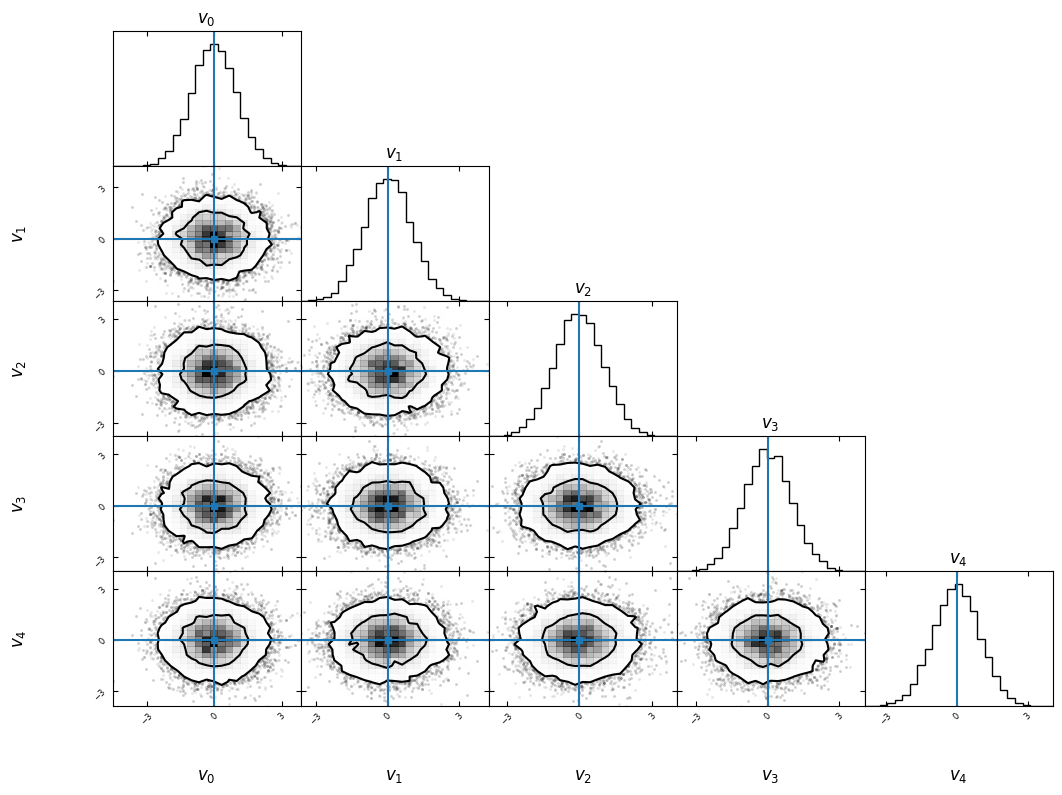

In [7]:
# A corner plot is a standard way to show the results of the sampler
# If the number of dimensions is large reducing the plot to a subspace may be necessary 
import corner

# Pretty labels aren't alway necessary but can greatly improve clarity; this is an example of how to create them

def get_labels(n_par):
    """get useful labels for corner plots"""
    labels = []
    for itrp in range(n_par):
        labels.append(r"$v_"+str(itrp)+"$")
    return labels

def format_samples_output(samples, params_fid):
    """format samples for outputting"""
    labels_loc = get_labels(params_fid.size)
    return samples.copy(), params_fid.copy(), labels_loc
    
# reformat the samples to make the plots look nicer
samples_format, params_true_format, labels = format_samples_output(mcc.samples_store[:,0,:].copy(), params_true)

# create the corner plot figure
fig = plt.figure(figsize=(10, 7.5))
figure = corner.corner(samples_format, fig=fig, bins=25, hist_kwargs={"density": True}, show_titles=True, title_fmt=None,
                       title_kwargs={"fontsize": 12}, labels=labels, max_n_ticks=3, label_kwargs={"fontsize": 12}, labelpad=0.15,
                       smooth=0.25, levels=[0.682, 0.954])

# overplot the true parameters
corner.overplot_points(figure, params_true_format[None], marker="s", color='tab:blue', markersize=4)
corner.overplot_lines(figure, params_true_format, color='tab:blue')

# adjust the figure to fit the box better
fig.subplots_adjust(wspace=0., hspace=0., left=0.05, top=0.95, right=0.99, bottom=0.05)
for ax in figure.get_axes():
    ax.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True, labelsize=6)
plt.show()

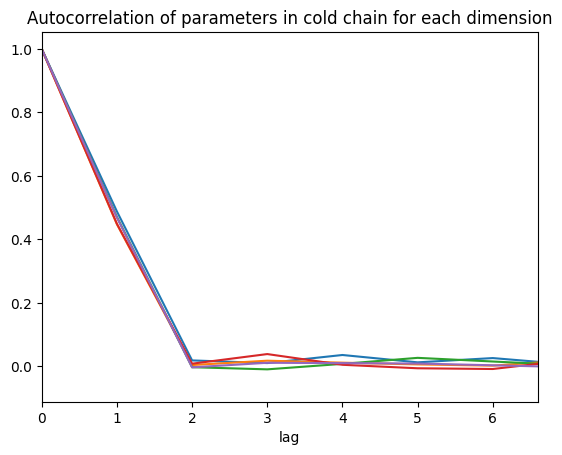

In [8]:
# The autocorrelation length summarizes how correlated samples in a given chain are with each other 
# We can compute the autocorrelation length for each dimension of the parameter space individually
# As well as the autocorrelation length for the likelihoods
# All else being equal, lower autocorrelation lengths always mean the sampler is performing better
# However, the autocorrelation can be artificially deflated if the sampler is missed some important structure completely
# If the sampler is exactly Markovian, autocorrelations should be positive semi-definite and monotonically decreasing 
# (Up to numerical noise)
# Therefore the shape of autocorrelation plots can be an important diagnostic of poor overall performance
# And examining the autocorrelations for each dimension separately can give ideas for where customized jumps might be helpful
# Note: when there are multiple chains at the same temperature, the autocorrelation length does not tell the full story:
# Cross correlations between chains can also be important diagnostics of the overall performance of the sampler

# Make some autocorrelation plots
autocorrs = np.array(corr_sum.autocorr_lims).copy()          # get the unnormalized correlations
autocorr_use = np.max(corr_sum.est_vars_auto/autocorrs[:,0]) # get the maximum autocorrelation length of  
autocorrs = (autocorrs.T/autocorrs[:,0]).T                        # get the properly normalized autocorrelation

plt.plot(autocorrs.T)
plt.xlim(0,3*autocorr_use)
plt.xlabel('lag')
plt.title('Autocorrelation of parameters in cold chain for each dimension')
plt.show()

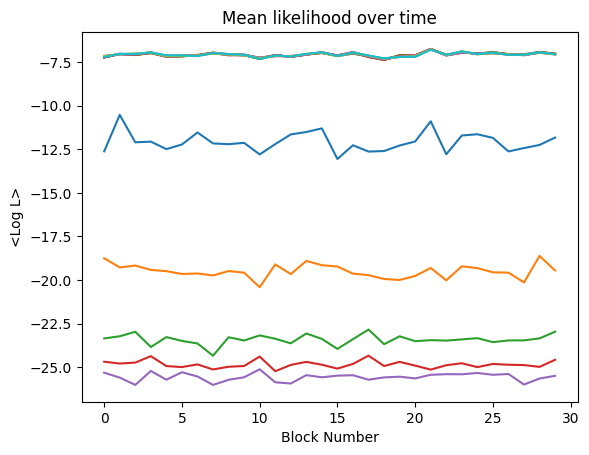

In [9]:
# Average Likelihoods
# The spacings between the average likelihoods of the chains can be an indicator of disconnects
# Relatively consistent spacing is good: large gaps may indicate a disconnection
# Such disconnections can be caused by poorly sampled phase transitions
# Burn-in can be considered likely complete when all chains have stabilized at an equilibrium mean likelihood
# If the mean likelihood of an individual chain varies a lot over the course of the evolution it can indicate nonstationarity
# Heat capacity diagnostics below can help spot where to add more chains if necessary

plt.plot(mcc.logL_means)
plt.xlabel('Block Number')
plt.ylabel('<Log L>')
plt.title('Mean likelihood over time')
plt.show()

In [ ]:
mcc

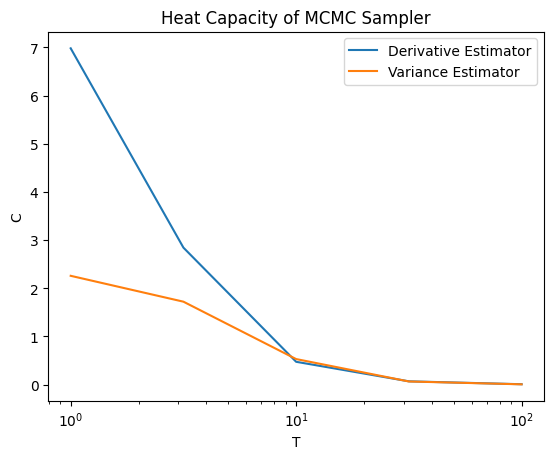

In [17]:
# The heat capacity is an important predictor of the efficiency of the temperature ladder
# In analogy to thermodynamics, the 'Energy' of a state is -<log L>
# So the 'heat capacity', thermodynamically defined as C=d<E>/dT, can be defined analogously C=-d <log L>/dT
# However, this is an inefficient way to actually estimate the heat capacity. 
# Using partition functions and thermodynamic assumptions, we can prove the following identity: 
# d<E>/dT = Var(E)/T^2.
# Var(E)/T^2 turns out to be a greatly superior estimator of the heat capacity, as can be seen below


# Note that I calculate the derivative using a change of variables beta=1/T to handle T->Infinity properly
plt.semilogx(mcc.Ts[mcc.n_cold-1:],np.gradient(mcc.logL_means[-1][mcc.n_cold-1:],mcc.betas[mcc.n_cold-1:])*mcc.betas[mcc.n_cold-1:]**2)
plt.semilogx(mcc.Ts[mcc.n_cold-1:],mcc.logL_vars[-1][mcc.n_cold-1:]/mcc.Ts[mcc.n_cold-1:]**2)
plt.legend(['Derivative Estimator','Variance Estimator'])
plt.xlabel('T')
plt.ylabel('C')
plt.title('Heat Capacity of MCMC Sampler')
plt.show()

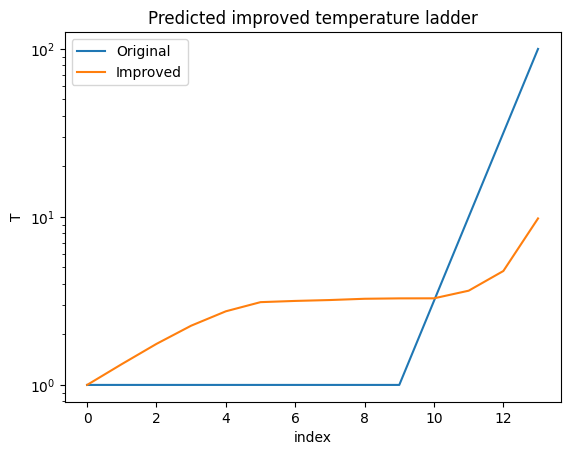

In [11]:
# Using the heat capacity
# we can predict what a more optimal temperature ladder 
# with the same number of temperatures might have looked like

Ts_predict = th.entropy_spacing_var(n_chain, mcc.betas, mcc.logL_vars[-1])

plt.semilogy(mcc.Ts)
plt.semilogy(Ts_predict)
plt.xlabel('index')
plt.ylabel('T')
plt.title('Predicted improved temperature ladder')
plt.legend(['Original','Improved'])



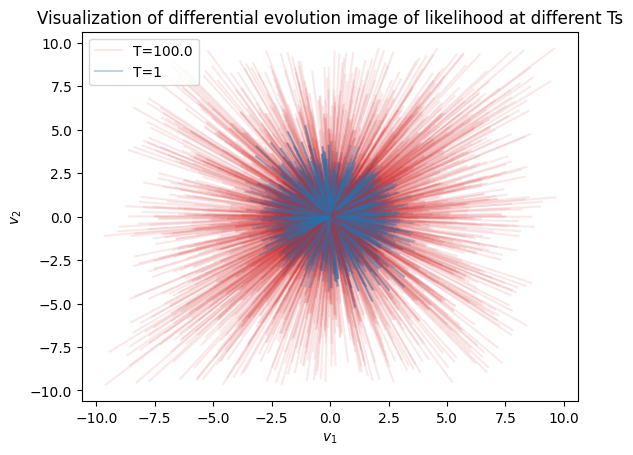

In [12]:
# What is differential evolution?
# Differential evolution is fundamentally a genetic algorithm 
# That automatically learns the two-point correlation structure of a problem
# It is very good at finding widely separated modes, and can explore strangely shaped contours
# It can suffer in very high dimensional problems
# An advantage of combining it with parallel tempering is that it can learn 
# the structure at multiple different temperatures at once

# Here is a visualization of what the differential evolution buffer learns

buffer_cold = de_manager.de_buffer[:,0,:]
buffer_hot = de_manager.de_buffer[:,-1,:]
n_samples = 50

samples_sel = np.random.randint(0,buffer_cold.shape[0],n_samples)
buffer_samples_cold = buffer_cold[samples_sel]
buffer_samples_hot = buffer_hot[samples_sel]


for itrd1 in range(buffer_samples_cold.shape[0]):
    for itrd2 in range(buffer_samples_cold.shape[0]):
        if itrd1 != itrd2:
            diff_cold = buffer_samples_cold[itrd1]-buffer_samples_cold[itrd2]
            diff_hot = buffer_samples_hot[itrd1]-buffer_samples_hot[itrd2]
            
            plt.plot([0,diff_hot[0]],[0,diff_hot[1]],color='tab:red',alpha=0.1)
            plt.plot([0,diff_cold[0]],[0,diff_cold[1]],color='tab:blue',alpha=0.3)

plt.xlabel(r'$v_1$')
plt.ylabel(r'$v_2$')
#plt.xlim(-10,10)
#plt.ylim(-10,10)
plt.legend(['T='+str(mcc.Ts[-2]),'T=1'],loc=0)
plt.title('Visualization of differential evolution image of likelihood at different Ts')
plt.show()